In [14]:
!git clone https://github.com/soumitra45-git/AI-ML-LAB-3-KmeansClustering.git

fatal: destination path 'AI-ML-LAB-3-KmeansClustering' already exists and is not an empty directory.


In [15]:
%cd AI-ML-LAB-3-KmeansClustering
!git pull origin main

/content/AI-ML-LAB-3-KmeansClustering
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 8 (delta 0), reused 8 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 708 bytes | 354.00 KiB/s, done.
From https://github.com/soumitra45-git/AI-ML-LAB-3-KmeansClustering
 * branch            main       -> FETCH_HEAD
   7ddb1a5..d8d2ce3  main       -> origin/main
Updating 7ddb1a5..d8d2ce3
Fast-forward
 dataset/custom_customers.csv                     | 11 +++++++++++
 mall_customers.csv => dataset/mall_customers.csv |  0
 model/New Text Document.txt                      |  0
 3 files changed, 11 insertions(+)
 create mode 100644 dataset/custom_customers.csv
 rename mall_customers.csv => dataset/mall_customers.csv (100%)
 create mode 100644 model/New Text Document.txt


In [16]:
%cd ..

/content


In [17]:
import pandas as pd

df = pd.read_csv(
    "/content/AI-ML-LAB-3-KmeansClustering/dataset/mall_customers.csv"
)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [18]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

df.describe()

(1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB
None
CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [19]:
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X = df[features]

In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X = imputer.fit_transform(X)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

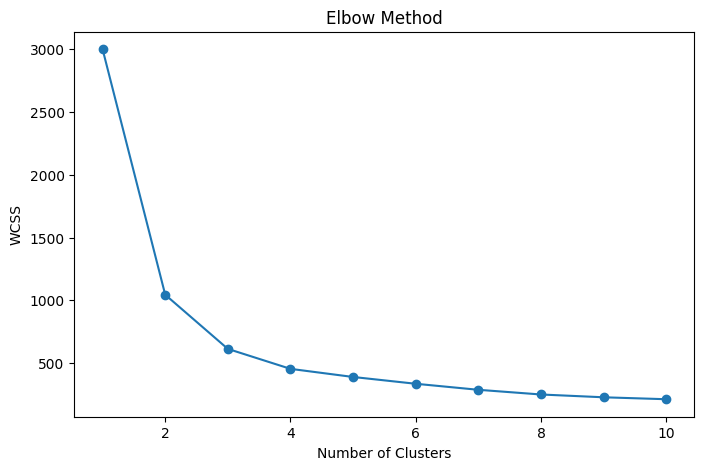

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [24]:
optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [25]:
df["Cluster"] = clusters

In [26]:
import joblib

joblib.dump(
    kmeans,
    "/content/AI-ML-LAB-3-KmeansClustering/model/kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "/content/AI-ML-LAB-3-KmeansClustering/model/scaler.pkl"
)

['/content/AI-ML-LAB-3-KmeansClustering/model/scaler.pkl']

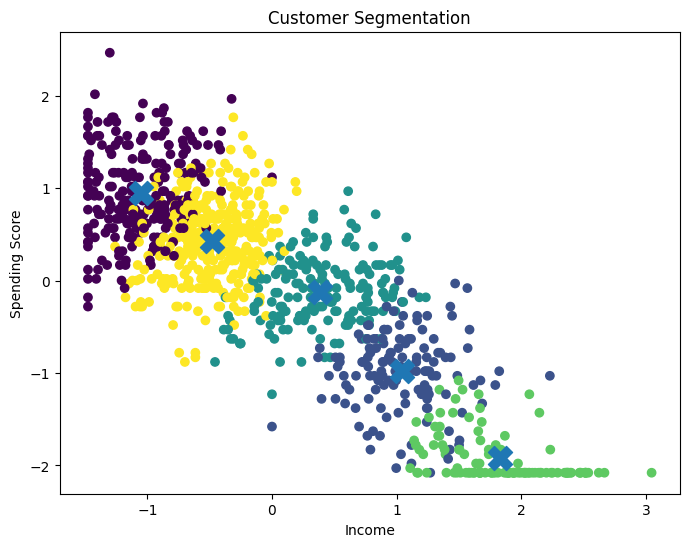

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,1],
    X_scaled[:,2],
    c=clusters
)

centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:,1],
    centroids[:,2],
    marker='X',
    s=300
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

In [28]:
custom_df = pd.read_csv(
    "/content/AI-ML-LAB-3-KmeansClustering/dataset/custom_customers.csv"
)

custom_df

,Age,Annual Income (k$),Spending Score (1-100)
0,20,15,90
1,22,20,85
2,24,25,80
3,35,60,40
4,38,65,45
5,40,70,50
6,50,90,20
7,55,95,15
8,28,45,70
9,32,55,60


In [29]:
custom_scaled = scaler.transform(
    custom_df
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [30]:
custom_clusters = kmeans.predict(
    custom_scaled
)

custom_df["Assigned Cluster"] = custom_clusters

custom_df

,Age,Annual Income (k$),Spending Score (1-100),Assigned Cluster
0,20,15,90,0
1,22,20,85,0
2,24,25,80,0
3,35,60,40,2
4,38,65,45,2
5,40,70,50,2
6,50,90,20,1
7,55,95,15,1
8,28,45,70,0
9,32,55,60,4


In [42]:
import joblib

joblib.dump(
    kmeans,
    "/content/AI-ML-LAB-3-KmeansClustering/model/kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "/content/AI-ML-LAB-3-KmeansClustering/model/scaler.pkl"
)

['/content/AI-ML-LAB-3-KmeansClustering/model/scaler.pkl']

In [44]:
%cd /content/AI-ML-LAB-3-KmeansClustering/model

/content/AI-ML-LAB-3-KmeansClustering/model


In [45]:
from google.colab import files

files.download("kmeans_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>